### PyTorch Workflow. ###

* Resources:
  1. https://www.learnpytorch.io/01_pytorch_workflow/
  2. https://docs.pytorch.org/docs/2.14/nn.html
* Content Cover:
  1. Data (Prepare and Load)
  2. Build Model
  3. Making Predictions and Evaluating a Model (Inference).
  4. Saving and loading a Model
  5. Putting it all toghethers

In [1]:
import torch
from torch import nn #-- nn means neural network. --#
import matplotlib.pyplot as plt
#-- Check PyTorch version. --#
print(f"Pytorch Version: {torch.__version__}")


Pytorch Version: 2.11.0+cpu


## 1. Data (Preparing and Loading). ##
  * Data has several different types including Excel Spreadsheet, Images, Videos, Audio, DNA, Text, and so on.
  * Machine Learning has two parts:
    + Get data into numerical representation.
    + Build a model to learn patterns in that numerical representation.
  * In this section, I'll use linear regression model with known **parameters**.

In [7]:
#-- Generate known parameters. --#
weight = 0.7
bias = 0.3
#-- Create. --#
start = 0
end = 1
step = 0.02
X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
y = weight*X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
len(X), len(y)

(50, 50)

## 2. Split into Training and Testing Sets. ##

In [14]:
#-- Generate Train Test Split. --#
train_split = int (0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
print(f"Len of X_train: {len(X_train)}")
print(f"Len of y_train: {len(y_train)}")
print(f"Len of X_test: {len(X_test)}")
print(f"Len of y_test: {len(y_test)}")

Len of X_train: 40
Len of y_train: 40
Len of X_test: 10
Len of y_test: 10


### 2.1 Visualize ###

In [23]:
def plot_predictions(train_data=X_train,
                      train_labels=y_train,
                      test_data=X_test,
                      test_labels=y_test,
                      predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10,7))
  #-- Plot training data in blue. --#
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  #-- Plot test data in green. --#
  plt.scatter(test_data, test_labels, c="g", s=4, label='Test Data')
  #-- Are there Predictions. --#
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label='Prediction')
  #-- Show. --#
  plt.legend(prop={'size':14})

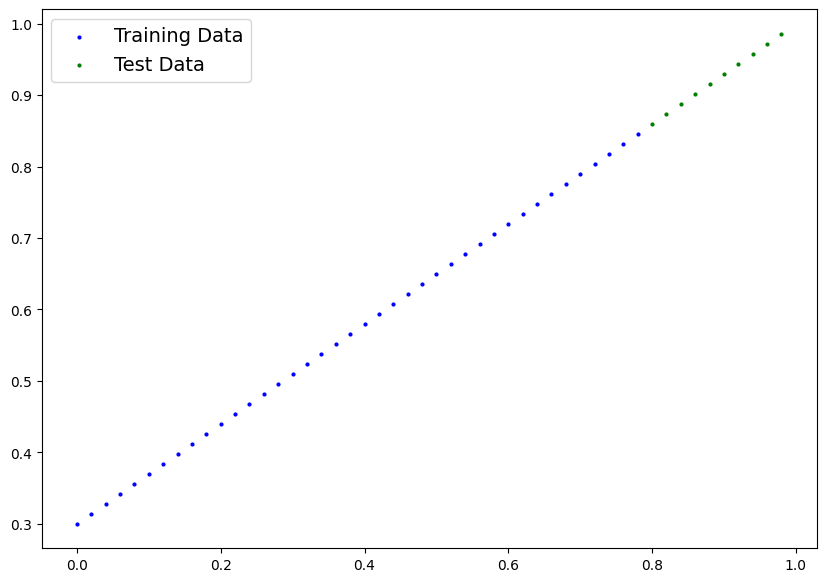

In [24]:
plot_predictions()

## 3. Build first model. ##

In [60]:
from torch import nn

class LinearRegressionModel(nn.Module): #<-- Almost everything in Pytorch inherit from nn.Module. --#
  def __init__(self):
    super().__init__()
    #-- Initialize Model Parameters. --#
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  #-- Forward method to define the computation in the model. --#
  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

### 3.1 PyTorch Essential Neural Network building Modules. ###

  1. torch.nn -> Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way).
  2. torch.nn.Module -> The base class for all neuron network modules, all the building blocks for neural networks are subclasses. If building a neural network in Pytorch, model should have subclass **nn.Module** which requires a **forward()** method can be implemented.
  3. torch.optim -> Contains various optimization algorithms (these tell the model parameters stored in **nn.Parameter** how to best change to improve gradient descent an in tur reduce the loss).
  4. torch.utils.data.Dataset -> Represents a map between key(label) and sample(features) pairs of data such as images and associated labels.
  5. torch.utils.dataset.DataLoader -> Creates a Python iterable over a torch Dataset (allows to iterate over data).
  6. Link: https://docs.pytorch.org/tutorials/index.html

In [62]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

### 3.2 Checking the content of PyTorch Model. ###

In [63]:
#-- Generate a random seed. --#
#-- torch.manual_seed(42). --#
#-- Generate an instance of the model. --#
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [64]:
#-- List name parameters. --#
model_0.state_dict()

OrderedDict([('weights', tensor([0.1288])), ('bias', tensor([0.2345]))])

## 4. Making Prediction using torch.inference_mode(). ##

In [68]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3375],
        [0.3401],
        [0.3427],
        [0.3452],
        [0.3478],
        [0.3504],
        [0.3530],
        [0.3555],
        [0.3581],
        [0.3607]], grad_fn=<AddBackward0>)

In [69]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [73]:
#-- Make prediction. --#
with torch.inference_mode():
  y_preds = model_0(X_test)
with torch.no_grad():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3375],
        [0.3401],
        [0.3427],
        [0.3452],
        [0.3478],
        [0.3504],
        [0.3530],
        [0.3555],
        [0.3581],
        [0.3607]])

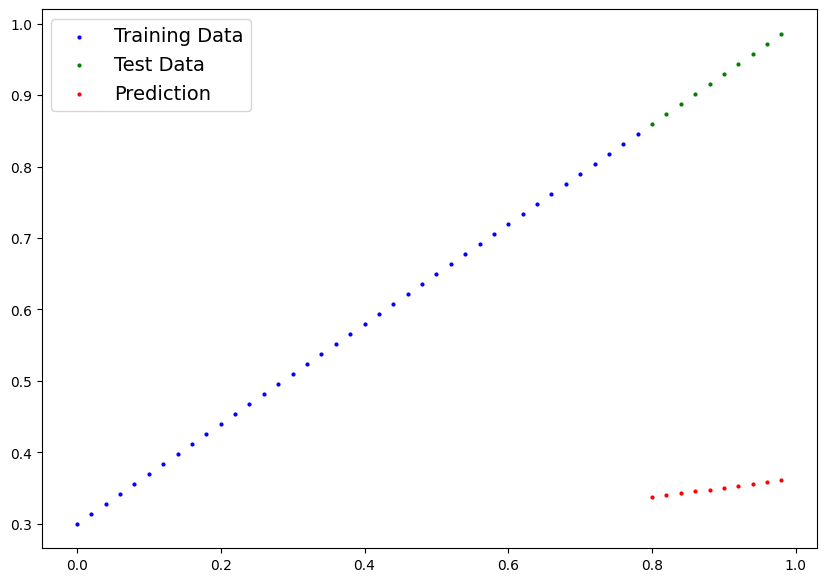

In [74]:
plot_predictions(predictions=y_preds)

## 5. Train the Model. ##

In [75]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [76]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.1288])), ('bias', tensor([0.2345]))])

In [79]:
#-- Setup a loss function. --#
loss_fn = nn.L1Loss()
#-- Setup an optimizer. --#
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.00001)

## 6. Training a Loop. ##

In [84]:
with torch.no_grad():
  model_0.parameters()

In [85]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [88]:
epochs = 1
for epoch in range(epochs):
  model_0.train()
  #-- Forward Pass. --#
  y_preds = model_0(X_train)
  #-- Calculate the loss. --#
  loss = loss_fn(y_preds, y_train)
  #-- Optimizer Zero Grad. --#
  optimizer.zero_grad()
  #-- Perform backpropagation. --#
  loss.backward()
  #-- Step the optimizer. --#
  optimizer.step()
  model_0.eval()